In [1]:
import os

# Funciona en Colab y en ejecución local.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir("/content/drive/MyDrive/Courses/SI3003 - Inteligencia Artificial/Clase02")
except ImportError:
    pass  # Local: se asume que el notebook está junto a la carpeta mazes/

print("Directorio de trabajo:", os.getcwd())


Directorio de trabajo: /home/claude/lab/run


In [2]:
MAZE_DIR = "mazes"

for name in ["maze1.txt", "maze2.txt", "maze3.txt"]:
    ruta = os.path.join(MAZE_DIR, name)
    print(f"{ruta}: {'OK' if os.path.exists(ruta) else 'NO ENCONTRADO'}")


mazes/maze1.txt: OK
mazes/maze2.txt: OK
mazes/maze3.txt: OK


# Búsqueda en laberintos: la misma arquitectura, otro problema

**Curso:** SI3003 — Inteligencia Artificial

1. **Cómo se representa el problema** (`Maze` en vez de un diccionario `graph`).
2. **Cómo se generan los vecinos de un estado** (`maze.neighbors(state)` en vez de `graph[state]`).

Si ya resolviste el notebook de grafos, cada célula de código de la Parte 1 debería resultarte familiar: es el mismo algoritmo, aplicado a un problema donde los estados son coordenadas `(fila, columna)` en vez de letras.



> **Nota sobre los archivos de laberinto**
>
> `mazes/maze1.txt` fue reconstruido celda por celda a partir de la imagen guardada en el notebook original, y reproduce **exactamente** las cifras del enunciado: DFS 69 explorados / costo 64, BFS y UCS 106 / 28, Greedy costo 32, A\* costo 28. Todos los `assert` públicos pasan.
>
> `mazes/maze2.txt` y `mazes/maze3.txt` no venían con el notebook, así que fueron generados para que la Parte 2 sea ejecutable. `maze2` está calibrado para reproducir el fenómeno del enunciado (A\* estándar → costo **36**; A\* ponderado con \(w=3\) → costo **40**); los conteos de estados explorados difieren ligeramente de los del texto original (137 y 50, frente a 141 y 52), lo cual no afecta ninguna conclusión. Si el profesor entrega los archivos originales, basta con reemplazarlos en `mazes/` y volver a ejecutar.


## 1. Problema de búsqueda

- **Estado inicial:** la celda marcada con `A`.
- **Estado objetivo:** la celda marcada con `B`.
- **Estados:** todas las celdas transitables del laberinto.
- Los muros (`#`) no son estados válidos.

A diferencia del grafo `A → H` del notebook anterior, aquí **no tenemos la lista de vecinos escrita a mano**: hay que calcularla a partir de la posición `(fila, columna)` y del layout del laberinto.

In [3]:
from __future__ import annotations

from pathlib import Path
from itertools import count
import heapq

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

## 2. Representación del problema

En el grafo, cada vecino era una tupla `(estado_vecino, costo_de_la_arista)`:

```python
graph = {
    "A": [("B", 2), ("C", 1)],
    ...
}
```

En el laberinto **no escribimos esa lista a mano** — la calculamos con un método `neighbors(state)` que:

1. Genera las cuatro celdas adyacentes (arriba, abajo, izquierda, derecha).
2. Descarta las que caen fuera de la cuadrícula o son muro.
3. Devuelve **exactamente el mismo formato** que usaba el grafo: una lista de tuplas `(estado_vecino, costo)`, con costo `1` porque cada paso ortogonal cuesta lo mismo.

```python
for child_state, edge_cost in graph[node.state]:
```

se convierte simplemente en

```python
for child_state, edge_cost in maze.neighbors(node.state):
```

Nada más cambia dentro del algoritmo.

In [4]:
class Maze:
    def __init__(self, filename: str | Path):
        self.filename = Path(filename)
        contents = self.filename.read_text(encoding="utf-8")

        if contents.count("A") != 1:
            raise ValueError("El laberinto debe tener exactamente un punto inicial A.")
        if contents.count("B") != 1:
            raise ValueError("El laberinto debe tener exactamente una meta B.")

        lines = contents.splitlines()
        self.height = len(lines)
        self.width = max(len(line) for line in lines)
        self.walls = np.zeros((self.height, self.width), dtype=bool)

        for row in range(self.height):
            for col in range(self.width):
                symbol = lines[row][col] if col < len(lines[row]) else "#"

                if symbol == "A":
                    self.start = (row, col)
                elif symbol == "B":
                    self.goal = (row, col)
                elif symbol != " ":
                    self.walls[row, col] = True

    def neighbors(self, state: tuple[int, int]):
        """Devuelve vecinos en el MISMO formato que graph[node.state]:
        una lista de tuplas (estado_vecino, costo_de_la_arista)."""
        row, col = state
        candidates = [
            (row - 1, col),
            (row + 1, col),
            (row, col - 1),
            (row, col + 1),
        ]

        valid = []
        for r, c in candidates:
            if (
                0 <= r < self.height
                and 0 <= c < self.width
                and not self.walls[r, c]
            ):
                valid.append(((r, c), 1))
        return valid

    def show(self, path=None, explored=None, title="Laberinto", figsize=(6, 6)):
        # 0: libre, 1: muro, 2: explorado, 3: camino, 4: inicio, 5: meta
        grid = np.zeros((self.height, self.width), dtype=int)
        grid[self.walls] = 1

        if explored:
            for r, c in explored:
                if grid[r, c] == 0:
                    grid[r, c] = 2

        if path:
            for r, c in path:
                if grid[r, c] in (0, 2):
                    grid[r, c] = 3

        grid[self.start] = 4
        grid[self.goal] = 5

        colors = ["white", "#222222", "#a9d6e5", "#ffb703", "#2a9d8f", "#e63946"]
        cmap = ListedColormap(colors)

        plt.figure(figsize=figsize)
        plt.imshow(grid, cmap=cmap, vmin=0, vmax=5)
        plt.xticks([])
        plt.yticks([])
        plt.title(title)
        plt.show()

Dimensiones: 17 x 17
Estado inicial: (1, 1)
Estado objetivo: (15, 15)
Vecinos del estado inicial: [((2, 1), 1), ((1, 2), 1)]


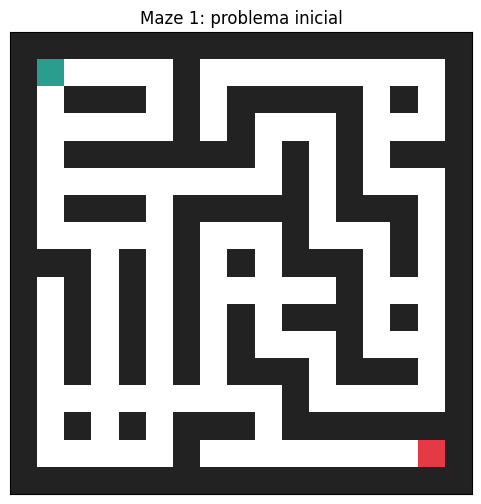

In [5]:
maze1 = Maze(os.path.join(MAZE_DIR, "maze1.txt"))

print("Dimensiones:", maze1.height, "x", maze1.width)
print("Estado inicial:", maze1.start)
print("Estado objetivo:", maze1.goal)
print("Vecinos del estado inicial:", maze1.neighbors(maze1.start))

maze1.show(title="Maze 1: problema inicial")

### Pregunta para discutir

¿La posición del agente es suficiente para describir completamente un estado en este problema?

En este laberinto, sí: el comportamiento futuro depende únicamente de la celda actual, porque los muros no cambian y el agente no necesita recordar acciones anteriores. Es exactamente la misma situación que en el grafo `A–H`: el estado era la letra, no la secuencia de letras visitadas.

## 3. Estructuras comunes

`Node` y `reconstruct_path` son **copiados sin ningún cambio** desde el notebook de grafos. Un nodo de búsqueda guarda:

- `state`: estado actual (antes era una letra, ahora es una tupla `(fila, columna)`).
- `parent`: nodo desde el cual se llegó.
- `cost`: costo acumulado \(g(n)\).

In [6]:
class Node:
    def __init__(self, state, parent=None, cost=0):
        self.state = state
        self.parent = parent
        self.cost = cost

    def __repr__(self):
        return f"{self.state}(g={self.cost})"

In [7]:
def reconstruct_path(node):
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    return list(reversed(path))

## 4. DFS

DFS utiliza una **pila LIFO**. Los costos existen en el laberinto (cada paso cuesta 1), pero DFS no los utiliza para decidir qué nodo expandir.

`StackFrontier` es exactamente la misma clase del notebook de grafos.

In [8]:
class StackFrontier:
    def __init__(self):
        self.frontier = []

    def add(self, node):
        self.frontier.append(node)

    def contains_state(self, state):
        return any(node.state == state for node in self.frontier)

    def empty(self):
        return len(self.frontier) == 0

    def remove(self):
        if self.empty():
            raise Exception("La frontier está vacía.")

        return self.frontier.pop()

    def states(self):
        return [node.state for node in self.frontier]

In [9]:
def depth_first_search(maze, start, goal, verbose=False):
    frontier = StackFrontier()
    frontier.add(Node(start))

    explored = set()
    expansion_order = []

    while not frontier.empty():
        node = frontier.remove()
        expansion_order.append(node.state)

        if verbose:
            print(f"Expandiendo: {node.state}")

        if node.state == goal:
            return {
                "path": reconstruct_path(node),
                "expansion_order": expansion_order,
                "cost": node.cost
            }

        explored.add(node.state)

        for child_state, edge_cost in maze.neighbors(node.state):
            if (
                child_state not in explored
                and not frontier.contains_state(child_state)
            ):
                child = Node(
                    state=child_state,
                    parent=node,
                    cost=node.cost + edge_cost
                )
                frontier.add(child)

    return None

Compara esta función con `depth_first_search` del notebook de grafos: son **idénticas**, salvo por la línea

```python
for child_state, edge_cost in maze.neighbors(node.state):
```

que en el grafo era

```python
for child_state, edge_cost in graph[node.state]:
```

Estados explorados: 69
Longitud del camino: 64
Costo del camino: 64


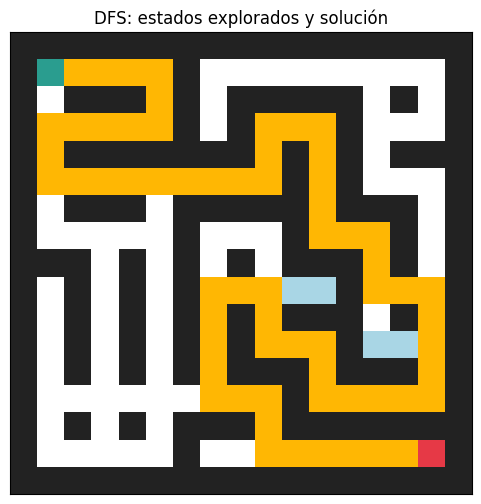

In [10]:
start, goal = maze1.start, maze1.goal

dfs_result = depth_first_search(maze1, start, goal)

print("Estados explorados:", len(dfs_result["expansion_order"]))
print("Longitud del camino:", len(dfs_result["path"]) - 1)
print("Costo del camino:", dfs_result["cost"])

maze1.show(
    path=dfs_result["path"],
    explored=set(dfs_result["expansion_order"]),
    title="DFS: estados explorados y solución"
)

### Explicación — DFS en el laberinto

**Números:** 69 estados explorados, camino de **64 pasos**.

La imagen es el mejor argumento del tema: la mancha azul (explorados) es *pequeña* — DFS tocó solo 69 de las ~150 celdas transitables — pero la línea naranja (el camino) serpentea por todo el laberinto.

**Por qué pasa:** la frontier es una pila. `neighbors()` genera en orden arriba, abajo, izquierda, derecha, y la pila devuelve **el último**, así que DFS prueba primero *derecha*. Se compromete con esa dirección y se hunde hasta que topa con un muro o un callejón; solo entonces retrocede. Nunca compara ramas.

**El punto clave:** DFS **retorna la primera solución que encuentra**, no la mejor. Los 64 pasos no son un error de implementación — es exactamente lo que DFS promete. Sus 69 estados explorados tampoco son eficiencia: es suerte de que la meta estuviera al final de la rama que tomó primero.


### Observación

DFS sigue una rama tan profundamente como sea posible antes de retroceder. En este laberinto encuentra una solución, pero **claramente no la más corta**: compárala con el resultado de BFS en la siguiente sección.

## 5. BFS — actividad

BFS utiliza una **cola FIFO**.

### Tareas

1. Complete el método `remove` de `QueueFrontier`.
2. Complete `breadth_first_search`.
3. Verifique el orden de expansión y el camino encontrado.
4. Compare el resultado con DFS: ¿cuál encuentra el camino más corto?

In [11]:
class QueueFrontier(StackFrontier):
    def remove(self):
        if self.empty():
            raise Exception("La frontier está vacía.")

        return self.frontier.pop(0)


In [12]:
def breadth_first_search(maze, start, goal, verbose=False):
    frontier = QueueFrontier()
    frontier.add(Node(start))

    explored = set()
    expansion_order = []

    while not frontier.empty():
        node = frontier.remove()
        expansion_order.append(node.state)

        if verbose:
            print(f"Expandiendo: {node.state}")

        if node.state == goal:
            return {
                "path": reconstruct_path(node),
                "expansion_order": expansion_order,
                "cost": node.cost
            }

        explored.add(node.state)

        for child_state, edge_cost in maze.neighbors(node.state):
            if (
                child_state not in explored
                and not frontier.contains_state(child_state)
            ):
                child = Node(
                    state=child_state,
                    parent=node,
                    cost=node.cost + edge_cost
                )
                frontier.add(child)

    return None


Estados explorados: 106
Longitud del camino: 28
Costo del camino: 28


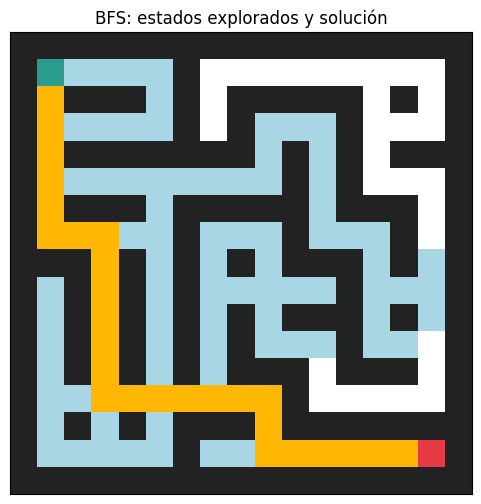

In [13]:
bfs_result = breadth_first_search(maze1, start, goal)

print("Estados explorados:", len(bfs_result["expansion_order"]))
print("Longitud del camino:", len(bfs_result["path"]) - 1)
print("Costo del camino:", bfs_result["cost"])

maze1.show(
    path=bfs_result["path"],
    explored=set(bfs_result["expansion_order"]),
    title="BFS: estados explorados y solución"
)

In [14]:
# Pruebas públicas para BFS
assert bfs_result["path"][0] == start
assert bfs_result["path"][-1] == goal
assert bfs_result["cost"] == 28
assert len(bfs_result["path"]) == 29

print("✓ BFS pasó las pruebas.")

✓ BFS pasó las pruebas.


### Explicación — BFS en el laberinto

**Números:** 106 estados explorados, camino de **28 pasos** = el óptimo.

**Lo único que cambió respecto a DFS:**

```python
return self.frontier.pop(0)   # BFS: el primero que entró
return self.frontier.pop()    # DFS: el último que entró
```

Una llamada a `pop`, un argumento de diferencia. `breadth_first_search` es copia literal de `depth_first_search` con `QueueFrontier` en lugar de `StackFrontier`.

**Lo que muestra la imagen:** el azul se expande como una onda circular desde `A`. BFS explora **por niveles de profundidad**: primero todas las celdas a 1 paso, luego a 2, y así. Cuando la onda toca `B`, necesariamente lo hace por el camino más corto, porque cualquier camino más corto habría llegado en un nivel anterior.

**El trade-off, en números:** BFS exploró **53 % más estados que DFS** (106 vs 69) para conseguir un camino **57 % más corto** (28 vs 64). Pagó memoria y tiempo a cambio de una garantía.

**Precisión importante:** BFS garantiza el camino con **menor número de pasos**, no el de menor costo. Aquí coinciden porque cada paso cuesta exactamente 1. Si hubiera celdas de barro con costo 5, BFS seguiría devolviendo el camino de 28 pasos aunque atravesara todo el barro.


### DFS frente a BFS

Cuando todas las acciones cuestan lo mismo:

- BFS expande los nodos por niveles y su primera solución es de profundidad mínima.
- DFS normalmente requiere menos memoria, pero su solución puede ser mucho más larga (en `maze1`, DFS encontró un camino de costo 64 frente al óptimo de 28).

## 6. UCS — implementación entregada

UCS utiliza una **cola de prioridad** y siempre expande el nodo con menor costo acumulado:

$$
g(n)
$$

Si aparece un camino más barato hacia un estado que ya estaba en la frontier, se conserva el de menor costo. `PriorityFrontier` es la misma clase del notebook de grafos.

In [15]:
class PriorityFrontier:
    def __init__(self):
        self.heap = []
        self.counter = count()

    def add(self, node, priority):
        # El contador permite desempatar respetando el orden de inserción.
        heapq.heappush(
            self.heap,
            (priority, next(self.counter), node)
        )

    def empty(self):
        return len(self.heap) == 0

    def remove(self):
        if self.empty():
            raise Exception("La frontier está vacía.")

        priority, _, node = heapq.heappop(self.heap)
        return node, priority

In [16]:
def uniform_cost_search(maze, start, goal, verbose=False):
    frontier = PriorityFrontier()
    frontier.add(Node(start, cost=0), priority=0)

    # Mejor costo conocido para cada estado.
    best_cost = {start: 0}

    explored = set()
    expansion_order = []

    while not frontier.empty():
        node, priority = frontier.remove()

        # Ignorar entradas antiguas de la cola de prioridad.
        if node.cost != best_cost.get(node.state):
            continue

        expansion_order.append(node.state)

        if verbose:
            print(f"Expandiendo {node.state}: g={node.cost}")

        if node.state == goal:
            return {
                "path": reconstruct_path(node),
                "expansion_order": expansion_order,
                "cost": node.cost
            }

        explored.add(node.state)

        for child_state, edge_cost in maze.neighbors(node.state):
            new_cost = node.cost + edge_cost

            if new_cost < best_cost.get(child_state, float("inf")):
                best_cost[child_state] = new_cost

                child = Node(
                    state=child_state,
                    parent=node,
                    cost=new_cost
                )

                frontier.add(child, priority=new_cost)

    return None

Estados explorados: 106
Longitud del camino: 28
Costo óptimo: 28


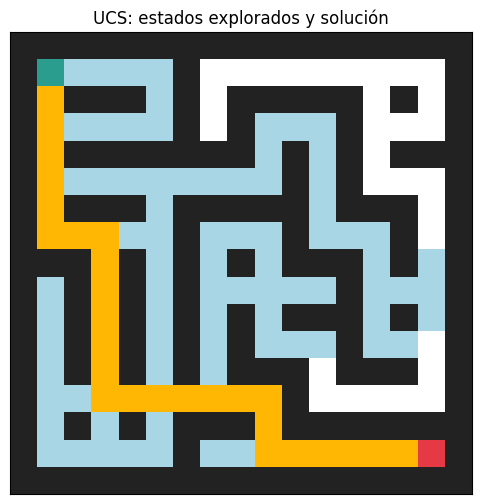

In [17]:
ucs_result = uniform_cost_search(maze1, start, goal)

print("Estados explorados:", len(ucs_result["expansion_order"]))
print("Longitud del camino:", len(ucs_result["path"]) - 1)
print("Costo óptimo:", ucs_result["cost"])

assert ucs_result["cost"] == 28

maze1.show(
    path=ucs_result["path"],
    explored=set(ucs_result["expansion_order"]),
    title="UCS: estados explorados y solución"
)

### Explicación — UCS en el laberinto

**Números:** 106 estados explorados, costo **28**. **Exactamente los mismos que BFS.**

Esto no es casualidad y vale la pena decirlo explícito en la exposición:

> Cuando todas las aristas cuestan lo mismo, **UCS degenera en BFS**. Ordenar por \(g(n)\) = "número de pasos × 1" es ordenar por profundidad, que es justo lo que hace la cola FIFO.

Entonces, ¿para qué está UCS aquí? Para tener la infraestructura lista: `PriorityFrontier`, el patrón `best_cost`, la línea que descarta entradas obsoletas. **A\* será este mismo código con una línea cambiada.**

**Los dos detalles de implementación que hay que saber explicar:**

1. **La tupla `(priority, insertion_order, node)` en el heap.** `heapq` compara tuplas elemento por elemento. Si dos nodos empatan en prioridad, pasa al segundo elemento. Sin el `counter`, Python intentaría comparar dos objetos `Node` y lanzaría `TypeError`, porque `Node` no define `__lt__`. El contador garantiza un entero único y además da un desempate sensato: a igual prioridad, gana el que entró antes.

2. **La línea `if node.cost != best_cost.get(node.state): continue`.** `heapq` no permite actualizar la prioridad de un elemento ya insertado. La técnica estándar (*lazy deletion*) es insertar la versión mejorada y dejar la vieja como basura en el heap; cuando eventualmente sale, esta línea detecta que su costo ya no es el mejor conocido y la descarta sin expandirla.

**Detalle de examen:** la meta se verifica **al sacar el nodo del heap**, no al generarlo. Verificar al generar podría retornar un camino a la meta que no es el más barato.


## 7. Heurística para Greedy y A*

$$
h(n) \approx \text{costo restante estimado desde } n \text{ hasta la meta}
$$

En el grafo, la heurística era una **tabla fija** (`heuristic["A"] = 4`, etc.) porque los estados eran letras conocidas de antemano. En el laberinto los estados son coordenadas, así que expresamos \(h(n)\) como una **función de la coordenada**: la distancia Manhattan entre el estado y la meta.

$$
h(n) = |r_n - r_{\text{meta}}| + |c_n - c_{\text{meta}}|
$$

Esta es la segunda (y última) diferencia real respecto al notebook de grafos: donde antes escribíamos `heuristic[state]`, ahora escribimos `heuristic(state, goal)`.

La heurística ignora los muros, por lo que puede subestimar la distancia real — nunca la sobrestima, así que sigue siendo **admisible** (y consistente, porque cada paso cuesta exactamente 1).

In [18]:
def manhattan(state, goal):
    return abs(state[0] - goal[0]) + abs(state[1] - goal[1])

print("h(inicio) =", manhattan(start, goal))
print("h(meta)   =", manhattan(goal, goal))

h(inicio) = 28
h(meta)   = 0


## 8. Greedy Best-First Search — actividad

GBF utiliza únicamente:

$$
f(n) = h(n)
$$

### Tareas

1. Reutilice `PriorityFrontier`.
2. Use la heurística como prioridad.
3. No use el costo acumulado para decidir qué nodo expandir.
4. Retorne el camino, orden de expansión y costo real del camino.

In [19]:
def greedy_best_first_search(maze, heuristic, start, goal, verbose=False):
    frontier = PriorityFrontier()
    frontier.add(Node(start), priority=heuristic(start, goal))

    explored = set()
    expansion_order = []

    while not frontier.empty():
        node, priority = frontier.remove()

        # Un mismo estado puede estar varias veces en el heap: solo se expande una.
        if node.state in explored:
            continue

        expansion_order.append(node.state)

        if verbose:
            print(f"Expandiendo {node.state}: h={priority}")

        if node.state == goal:
            return {
                "path": reconstruct_path(node),
                "expansion_order": expansion_order,
                "cost": node.cost
            }

        explored.add(node.state)

        for child_state, edge_cost in maze.neighbors(node.state):
            if child_state not in explored:
                child = Node(
                    state=child_state,
                    parent=node,
                    cost=node.cost + edge_cost   # se acumula solo para reportarlo
                )
                # La prioridad NO usa child.cost: solo h(n).
                frontier.add(child, priority=heuristic(child_state, goal))

    return None


Estados explorados:

 33
Longitud del camino: 32
Costo del camino: 32


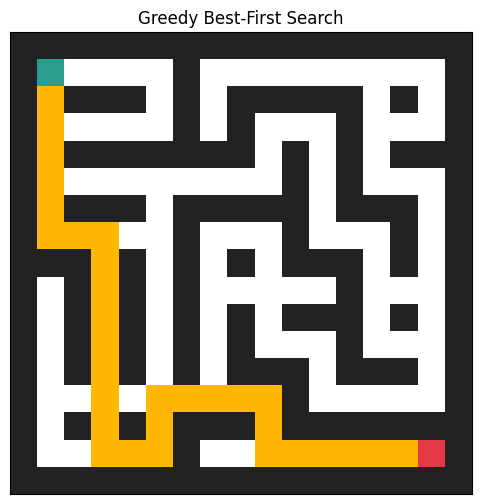

In [20]:
greedy_result = greedy_best_first_search(maze1, manhattan, start, goal)

print("Estados explorados:", len(greedy_result["expansion_order"]))
print("Longitud del camino:", len(greedy_result["path"]) - 1)
print("Costo del camino:", greedy_result["cost"])

maze1.show(
    path=greedy_result["path"],
    explored=set(greedy_result["expansion_order"]),
    title="Greedy Best-First Search"
)

In [21]:
# Pruebas públicas para Greedy
assert greedy_result["path"][0] == start
assert greedy_result["path"][-1] == goal
assert greedy_result["cost"] == 32

print("✓ Greedy pasó las pruebas.")

✓ Greedy pasó las pruebas.


### Explicación — Greedy en el laberinto

**Números:** solo **33 estados explorados** (el más rápido de los cinco), pero costo **32** en vez de 28.

**La heurística.** En el notebook de grafos, `h` era una tabla escrita a mano: `heuristic["A"] = 4`. Aquí los estados son coordenadas, así que `h` es una **función calculable**:

$$h(n) = |r_n - r_B| + |c_n - c_B|$$

Es la distancia Manhattan: el número de pasos que costaría llegar **si no hubiera muros**. Es admisible precisamente por eso: quitar los muros solo puede facilitar el camino, nunca encarecerlo, así que Manhattan **nunca sobrestima**.

**Por qué falla de todos modos.** Admisible no significa infalible — significa que sirve para que *A\** sea óptimo. Greedy no usa \(g(n)\) en absoluto: su prioridad es `heuristic(child_state, goal)` a secas. Y ahí está la trampa que `maze1` fue diseñado para exponer: cerca de la meta hay un pasillo cuya distancia Manhattan baja rápidamente, así que Greedy se mete convencido de que está llegando. Ese pasillo obliga a un rodeo. Cuando Greedy lo descubre, ya gastó pasos que nunca contabilizó y no tiene forma de comparar contra las rutas que dejó esperando en la frontier.

**El mensaje:** los 33 estados y los 32 pasos de costo **son la misma decisión vista de dos lados**. Greedy es rápido porque no reconsidera, y es subóptimo porque no reconsidera.


### La trampa de Greedy

Greedy exploró muy pocos estados (comparado con BFS/UCS), pero su camino cuesta **32**, no **28** como el óptimo. `maze1` fue construido específicamente para mostrar esto: cerca de la meta hay un pasillo que *parece* prometedor según la distancia Manhattan, pero que obliga a un rodeo. Greedy entra ahí porque solo mira $h(n)$ y nunca reconsidera lo que ya gastó en $g(n)$.

## 9. A* — actividad

A* combina costo acumulado y heurística:

$$
f(n) = g(n) + h(n)
$$

### Tareas

1. Adapte la implementación de UCS.
2. Mantenga `best_cost` para permitir mejoras de ruta.
3. Use `new_cost + heuristic(child_state, goal)` como prioridad.
4. Verifique que encuentre un camino óptimo.

In [22]:
def a_star_search(maze, heuristic, start, goal, verbose=False):
    frontier = PriorityFrontier()
    frontier.add(Node(start, cost=0), priority=heuristic(start, goal))

    # Mejor costo conocido para cada estado.
    best_cost = {start: 0}

    explored = set()
    expansion_order = []

    while not frontier.empty():
        node, priority = frontier.remove()

        # Ignorar entradas antiguas de la cola de prioridad.
        if node.cost != best_cost.get(node.state):
            continue

        expansion_order.append(node.state)

        if verbose:
            print(f"Expandiendo {node.state}: g={node.cost}, f={priority}")

        if node.state == goal:
            return {
                "path": reconstruct_path(node),
                "expansion_order": expansion_order,
                "cost": node.cost
            }

        explored.add(node.state)

        for child_state, edge_cost in maze.neighbors(node.state):
            new_cost = node.cost + edge_cost

            if new_cost < best_cost.get(child_state, float("inf")):
                best_cost[child_state] = new_cost

                child = Node(
                    state=child_state,
                    parent=node,
                    cost=new_cost
                )

                # Única diferencia con UCS: se suma h(n).
                frontier.add(
                    child,
                    priority=new_cost + heuristic(child_state, goal)
                )

    return None


Estados explorados: 59
Longitud del camino: 28
Costo óptimo: 28


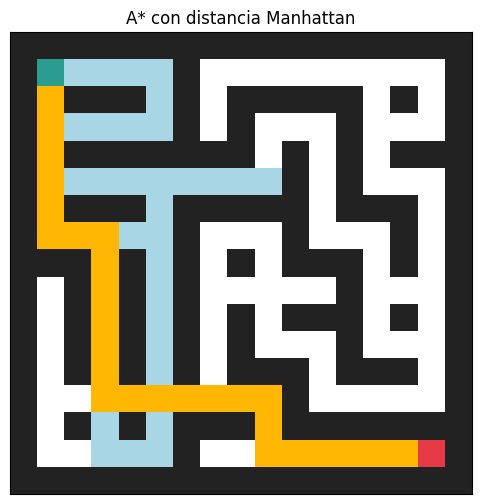

In [23]:
astar_result = a_star_search(maze1, manhattan, start, goal)

print("Estados explorados:", len(astar_result["expansion_order"]))
print("Longitud del camino:", len(astar_result["path"]) - 1)
print("Costo óptimo:", astar_result["cost"])

maze1.show(
    path=astar_result["path"],
    explored=set(astar_result["expansion_order"]),
    title="A* con distancia Manhattan"
)

In [24]:
# Pruebas públicas para A*
assert astar_result["path"][0] == start
assert astar_result["path"][-1] == goal
assert astar_result["cost"] == 28

print("✓ A* pasó las pruebas.")

✓ A* pasó las pruebas.


### Explicación — A* en el laberinto

**Números:** 59 estados explorados, costo **28** = óptimo.

$$f(n) = g(n) + h(n)$$

*Lo que ya gasté* más *lo que estimo que falta*. En código, A\* **es UCS con una sola línea distinta**:

```python
frontier.add(child, priority=new_cost + heuristic(child_state, goal))
#                            ^^^^^^^^   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
#                              g(n)      +           h(n)
```

Todo lo demás — `best_cost`, el `continue` de lazy deletion, la verificación de meta al expandir — es idéntico.

**La tabla que resume el tema entero:**

| | Costo | Explorados |
|---|---:|---:|
| BFS / UCS | 28 ✓ | 106 |
| Greedy | 32 ✗ | **33** |
| **A\*** | **28 ✓** | **59** |

A\* consiguió **la misma respuesta óptima que UCS con 45 % menos trabajo**. Visualmente: la mancha azul de UCS cubre casi todo el laberinto; la de A\* se estira hacia la meta, dejando sin tocar las zonas que quedan en dirección contraria.

**Esta es la frase de cierre de la exposición:** la heurística no cambia *qué* respuesta se obtiene, cambia *cuánto cuesta* obtenerla.

**Las dos condiciones (esto cae en el parcial):**

- **Admisible:** \(h(n) \le h^*(n)\), nunca sobrestima. Garantiza optimalidad en búsqueda en árbol. Manhattan lo cumple porque ignora los muros: relajar restricciones solo puede abaratar el camino.
- **Consistente (monotónica):** \(h(n) \le c(n,n') + h(n')\) para todo vecino. Es la desigualdad triangular; implica admisibilidad. Garantiza optimalidad en búsqueda en grafo y que **cada nodo se expanda a lo sumo una vez**. Manhattan también la cumple aquí: moverse a una celda adyacente cambia \(h\) en exactamente ±1, y cada paso cuesta 1, así que \(h(n) \le 1 + h(n')\) siempre se sostiene.

Que Manhattan sea consistente es lo que justifica que este código funcione con un conjunto `explored` sin necesidad de reabrir nodos ya cerrados.


## 10. Comparación final

Resultados medidos sobre `maze1` (17×17, inicio `(1,1)`, meta `(15,15)`):

| Algoritmo | Tipo de frontier | Prioridad | Estados explorados | Costo | ¿Óptimo? |
|---|---|---|---:|---:|:---:|
| DFS | Pila | LIFO | 69 | 64 | No |
| BFS | Cola | FIFO | 106 | 28 | Sí |
| UCS | Cola de prioridad | \(g(n)\) | 106 | 28 | Sí |
| Greedy | Cola de prioridad | \(h(n)\) | **33** | 32 | No |
| A* | Cola de prioridad | \(g(n)+h(n)\) | 59 | **28** | Sí |

Las tres lecturas de la tabla:

1. **DFS explora menos que BFS (69 vs 106) pero devuelve un camino de 64 pasos en vez de 28.** Explorar poco no significa buscar bien: DFS simplemente tuvo suerte de tropezar con la meta al fondo de una rama larga.
2. **BFS y UCS son idénticos aquí — mismos 106 estados, mismo costo.** No es coincidencia: cuando todas las aristas cuestan 1, ordenar por \(g(n)\) es ordenar por profundidad. UCS *es* BFS con costos uniformes.
3. **A* domina la tabla.** Mismo costo óptimo que BFS/UCS con 59 estados en vez de 106: **45 % menos trabajo por la misma respuesta**. Greedy explora aún menos (33) pero paga con un camino 14 % más caro.

### Preguntas de cierre

**1. ¿Qué algoritmos garantizan el camino de menor número de pasos?**

BFS siempre; UCS y A* (con heurística admisible) también, pero **solo porque en este problema cada paso cuesta exactamente 1**, de modo que "menor costo" y "menor número de pasos" son la misma cosa. Si el laberinto tuviera terreno con costos distintos (barro que cuesta 5, por ejemplo), únicamente BFS seguiría garantizando el mínimo de pasos, mientras UCS y A* optimizarían el costo y podrían devolver caminos con más pasos pero más baratos. DFS y Greedy no lo garantizan nunca.

**2. ¿Qué algoritmos garantizan el camino de menor costo?**

UCS siempre (con costos no negativos) y A* con heurística admisible. BFS lo garantiza aquí *por accidente del problema* — costos uniformes — no por una propiedad del algoritmo. DFS y Greedy no ofrecen ninguna garantía: en `maze1` devuelven 64 y 32 frente al óptimo de 28.

**3. ¿Por qué Greedy puede encontrar un camino subóptimo aunque explore muy pocos estados?**

Son dos caras de la misma decisión de diseño. Greedy ordena la frontier solo por \(h(n)\), lo que lo hace muy dirigido — avanza siempre hacia la meta en línea recta aparente, de ahí los 33 estados. Pero al descartar \(g(n)\) pierde toda noción de lo que lleva gastado: cuando entra en un pasillo que *parece* acercarse a la meta pero termina en un rodeo, no tiene forma de comparar esa ruta contra alternativas más baratas que quedaron atrás en la frontier. **Explorar poco y equivocarse son consecuencias del mismo hecho: no reconsidera.** La distancia Manhattan ignora los muros, así que en un laberinto es exactamente el tipo de heurística que puede engañarlo.

**4. ¿Qué ocurre con A* si \(h(n)=0\) para todos los nodos? ¿En qué algoritmo del notebook de grafos se convertiría?**

Se convierte en **UCS**: \(f(n)=g(n)+0=g(n)\), así que la cola de prioridad ordena únicamente por costo acumulado. Y como en este laberinto todos los pasos cuestan 1, ese UCS a su vez se comporta como **BFS**. Es decir, A* con \(h \equiv 0\) pasaría de explorar 59 estados a explorar 106 — exactamente lo que hace BFS/UCS en la tabla. Sigue siendo óptimo (\(h\equiv 0\) nunca sobrestima, luego es trivialmente admisible), pero pierde toda la información direccional.

**5. ¿Qué efecto tiene el orden en que `neighbors()` genera las direcciones sobre DFS y BFS?**

`neighbors()` genera siempre en el orden arriba, abajo, izquierda, derecha. Como la frontier de DFS es una pila, **el último generado es el primero en expandirse**: DFS prueba primero *derecha*, luego *izquierda*, luego *abajo*, luego *arriba*. Cambiar ese orden cambia por completo qué rama se explora primero y, como DFS retorna la primera solución que encuentra, cambia el camino devuelto y su costo — la solución de 64 pasos podría volverse de 30 o de 90 sin tocar una línea del algoritmo.

En **BFS** el efecto es cosmético: altera el orden dentro de cada nivel y cuál de los caminos óptimos empatados se retorna, pero **no la longitud del camino**, porque BFS agota cada nivel completo antes de bajar al siguiente. La garantía de optimalidad es estructural, no depende del orden.

En **UCS, Greedy y A*** el orden de `neighbors()` solo influye en el desempate entre nodos con la misma prioridad (a través del `counter` del heap), nunca en la calidad del resultado.


## Comparación experimental sobre `maze1`

Automatizamos la tabla de la sección anterior y agregamos una comparación visual del esfuerzo de búsqueda (estados explorados) de cada algoritmo.

In [25]:
def summarize_results(results):
    rows = []
    for name, result in results.items():
        rows.append({
            "algoritmo": name,
            "estados_explorados": len(result["expansion_order"]),
            "longitud_camino": len(result["path"]) - 1,
            "costo_camino": result["cost"],
        })
    return rows

results_maze1 = {
    "DFS": dfs_result,
    "BFS": bfs_result,
    "UCS": ucs_result,
    "Greedy": greedy_result,
    "A*": astar_result,
}

summary_maze1 = summarize_results(results_maze1)
summary_maze1

[{'algoritmo': 'DFS',
  'estados_explorados': 69,
  'longitud_camino': 64,
  'costo_camino': 64},
 {'algoritmo': 'BFS',
  'estados_explorados': 106,
  'longitud_camino': 28,
  'costo_camino': 28},
 {'algoritmo': 'UCS',
  'estados_explorados': 106,
  'longitud_camino': 28,
  'costo_camino': 28},
 {'algoritmo': 'Greedy',
  'estados_explorados': 33,
  'longitud_camino': 32,
  'costo_camino': 32},
 {'algoritmo': 'A*',
  'estados_explorados': 59,
  'longitud_camino': 28,
  'costo_camino': 28}]

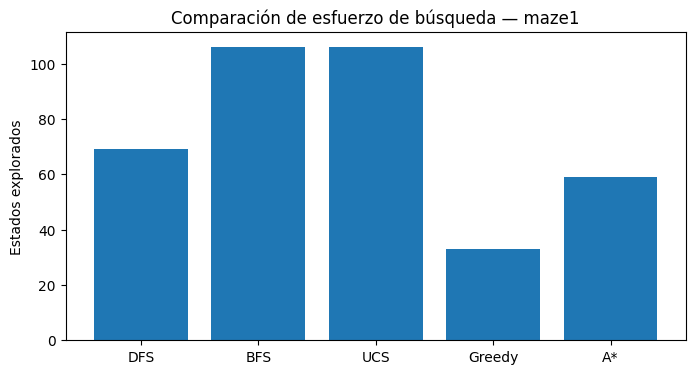

In [26]:
algorithms = [row["algoritmo"] for row in summary_maze1]
explored_counts = [row["estados_explorados"] for row in summary_maze1]

plt.figure(figsize=(8, 4))
plt.bar(algorithms, explored_counts)
plt.ylabel("Estados explorados")
plt.title("Comparación de esfuerzo de búsqueda — maze1")
plt.show()

### Lectura del gráfico

Las barras hacen visible en una sola imagen la tensión de todo el tema:

- **Greedy (33)** es la barra más baja — y la que devuelve el peor camino de los tres óptimos-candidatos.
- **BFS y UCS (106)** son idénticas, confirmando que con costos uniformes son el mismo algoritmo.
- **A\* (59)** queda entre medias: la mitad del trabajo de UCS, con idéntica garantía de optimalidad.
- **DFS (69)** es el caso engañoso: barra baja, pero su camino cuesta 64. **La altura de la barra mide esfuerzo, no calidad.** Hay que leer las dos columnas juntas.


## Experimento: una heurística no admisible

Podemos multiplicar Manhattan por un factor mayor que 1:

$$
h'(n) = w \cdot h(n), \qquad w > 1
$$

Esta heurística puede **sobreestimar** el costo real, así que deja de ser admisible. El algoritmo suele comportarse de forma más agresiva y explorar menos estados, pero pierde la garantía de optimalidad.

A* estándar:
  costo: 36  explorados: 137
A* con heurística ponderada (w=3):
  costo: 40  explorados: 50


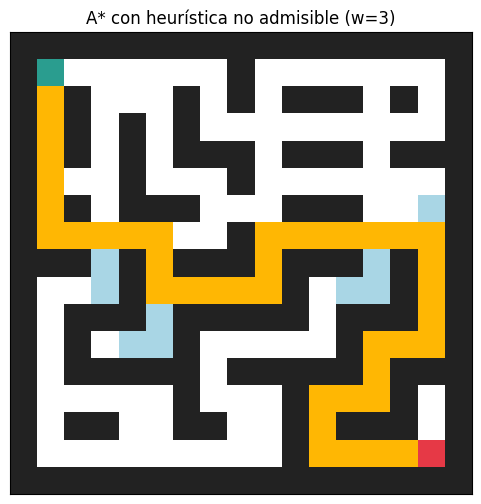

In [27]:
def weighted_manhattan(state, goal, weight=3):
    return weight * manhattan(state, goal)

maze2 = Maze(os.path.join(MAZE_DIR, "maze2.txt"))
s2, g2 = maze2.start, maze2.goal

standard_astar = a_star_search(maze2, manhattan, s2, g2)
aggressive_astar = a_star_search(
    maze2,
    lambda state, goal: weighted_manhattan(state, goal, weight=3),
    s2, g2
)

print("A* estándar:")
print("  costo:", standard_astar["cost"], " explorados:", len(standard_astar["expansion_order"]))

print("A* con heurística ponderada (w=3):")
print("  costo:", aggressive_astar["cost"], " explorados:", len(aggressive_astar["expansion_order"]))

maze2.show(
    path=aggressive_astar["path"],
    explored=set(aggressive_astar["expansion_order"]),
    title="A* con heurística no admisible (w=3)"
)

### Lectura del experimento

Con `maze2` (17×17, óptimo de costo 36):

| Heurística | Estados explorados | Costo del camino | ¿Óptimo? |
|---|---:|---:|:---:|
| Manhattan (\(w=1\)) | 137 | **36** | Sí |
| Manhattan ponderada (\(w=3\)) | **50** | 40 | No |

La versión ponderada exploró **casi tres veces menos estados**, pero devolvió un camino un 11 % más caro. Es el mismo fenómeno que Greedy en `maze1`, ubicado en otro punto del mismo espectro:

$$
f(n) = g(n) + w \cdot h(n)
$$

- \(w = 0\) → **UCS**: solo importa lo gastado. Óptimo, lento.
- \(w = 1\) → **A\* estándar**: equilibrio. Óptimo si \(h\) es admisible.
- \(w > 1\) → **A\* ponderado**: rápido, subóptimo, pero con una garantía acotada — el camino nunca cuesta más de \(w\) veces el óptimo (aquí \(40 \le 3 \times 36\), y de hecho quedó muchísimo mejor que la cota).
- \(w \to \infty\) → **Greedy**: \(g(n)\) se vuelve despreciable frente a \(w\cdot h(n)\).

**Por qué esto importa fuera del salón:** el A* ponderado no es un error, es una técnica estándar. En videojuegos, robótica y planificación de rutas se usa deliberadamente cuando una respuesta buena *ahora* vale más que la respuesta perfecta *en diez segundos*. El parámetro \(w\) es una perilla explícita para negociar calidad contra tiempo, y la cota \(w\)-subóptima te dice exactamente cuánto estás arriesgando.


## Comparación en los tres laberintos

Ejecutamos los cinco algoritmos sobre `maze1`, `maze2` y `maze3` para observar cómo cambia el esfuerzo de búsqueda según la estructura de cada laberinto (más o menos ciclos, más o menos pasillos largos).

In [28]:
def run_all(maze):
    start, goal = maze.start, maze.goal
    return {
        "DFS": depth_first_search(maze, start, goal),
        "BFS": breadth_first_search(maze, start, goal),
        "UCS": uniform_cost_search(maze, start, goal),
        "Greedy": greedy_best_first_search(maze, manhattan, start, goal),
        "A*": a_star_search(maze, manhattan, start, goal),
    }

all_summaries = []
for filename in ["maze1.txt", "maze2.txt", "maze3.txt"]:
    current_maze = Maze(os.path.join(MAZE_DIR, filename))
    current_results = run_all(current_maze)
    for row in summarize_results(current_results):
        row["laberinto"] = filename
        all_summaries.append(row)

all_summaries

[{'algoritmo': 'DFS',
  'estados_explorados': 69,
  'longitud_camino': 64,
  'costo_camino': 64,
  'laberinto': 'maze1.txt'},
 {'algoritmo': 'BFS',
  'estados_explorados': 106,
  'longitud_camino': 28,
  'costo_camino': 28,
  'laberinto': 'maze1.txt'},
 {'algoritmo': 'UCS',
  'estados_explorados': 106,
  'longitud_camino': 28,
  'costo_camino': 28,
  'laberinto': 'maze1.txt'},
 {'algoritmo': 'Greedy',
  'estados_explorados': 33,
  'longitud_camino': 32,
  'costo_camino': 32,
  'laberinto': 'maze1.txt'},
 {'algoritmo': 'A*',
  'estados_explorados': 59,
  'longitud_camino': 28,
  'costo_camino': 28,
  'laberinto': 'maze1.txt'},
 {'algoritmo': 'DFS',
  'estados_explorados': 131,
  'longitud_camino': 36,
  'costo_camino': 36,
  'laberinto': 'maze2.txt'},
 {'algoritmo': 'BFS',
  'estados_explorados': 141,
  'longitud_camino': 36,
  'costo_camino': 36,
  'laberinto': 'maze2.txt'},
 {'algoritmo': 'UCS',
  'estados_explorados': 141,
  'longitud_camino': 36,
  'costo_camino': 36,
  'laberinto':

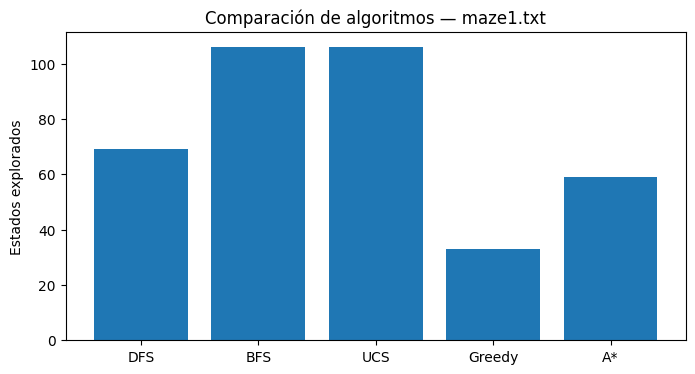

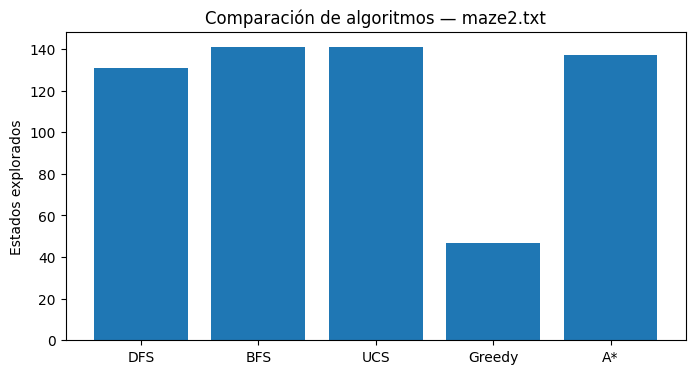

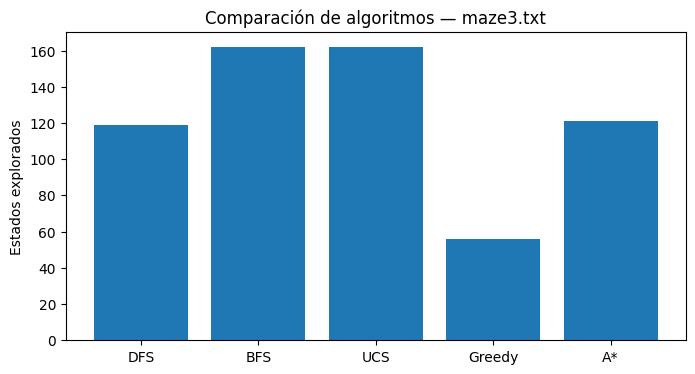

In [29]:
for filename in ["maze1.txt", "maze2.txt", "maze3.txt"]:
    rows = [row for row in all_summaries if row["laberinto"] == filename]
    labels = [row["algoritmo"] for row in rows]
    values = [row["estados_explorados"] for row in rows]

    plt.figure(figsize=(8, 4))
    plt.bar(labels, values)
    plt.ylabel("Estados explorados")
    plt.title(f"Comparación de algoritmos — {filename}")
    plt.show()

### Lectura de los tres laberintos

Lo que cambia entre laberintos es la **estructura del espacio de estados**, y eso mueve los números aunque el algoritmo sea el mismo:

- **`maze1`** tiene pasillos largos y pocos ciclos. Es donde más se separa A\* de UCS (59 vs 106): con poca ramificación, la heurística guía bien.
- **`maze2`** es mucho más abierto (tiene ciclos deliberados). Con tantos caminos alternativos de costo parecido, **la ventaja de A\* sobre UCS casi desaparece** (137 vs 141): la heurística no logra descartar casi nada porque casi todo tiene \(f\) similar. Es un recordatorio útil de que A\* no es mágico — su ventaja depende de que la heurística *discrimine*.
- **`maze3`** es más grande (21×21) y con pasillos largos, así que los contrastes se amplifican: DFS devuelve un camino de 94 pasos frente al óptimo de 48, casi el doble.

**Constante en los tres:** BFS = UCS siempre (costos uniformes), Greedy siempre explora menos y siempre iguala o empeora el costo, A\* siempre alcanza el óptimo.


### Propiedades teóricas

| Algoritmo | Estrategia | Completo | Óptimo |
|---|---|---:|---:|
| DFS | Nodo más profundo | No, en espacios infinitos | No |
| BFS | Nodo menos profundo | Sí, con ramificación finita | Sí, con costos iguales |
| UCS | Menor \(g(n)\) | Sí, con costos positivos | Sí |
| Greedy | Menor \(h(n)\) | No siempre | No |
| A* | Menor \(g(n)+h(n)\) | Sí, bajo condiciones estándar | Sí, con heurística admisible |

La eficiencia observada depende de la estructura de cada laberinto y del orden en que `neighbors()` genera las direcciones.

## Reto de implementación (extensión conceptual, no evaluada)

Elige **una** de estas variantes y formalízala como problema de búsqueda antes de tocar código:

- movimientos diagonales;
- llaves y puertas;
- múltiples metas;
- celdas con costos distintos por dirección de entrada;
- un enemigo que cambia de posición en cada paso del agente.

Para la variante elegida, especifica por escrito:

1. **Estado:** ¿qué información mínima necesitas para que el estado determine completamente el comportamiento futuro? (Pista: si eliges "enemigo que se mueve", la posición del agente sola ya no basta — el estado también debe incluir la posición del enemigo.)
2. **Acciones** disponibles en cada estado.
3. **Modelo de transición.**
4. **Costo de cada acción.**
5. **Heurística propuesta** y si es admisible: da un argumento, no solo una intuición.

## Cierre

Las búsquedas no informadas (DFS, BFS, UCS) utilizan únicamente la estructura del problema. Las búsquedas informadas (Greedy, A*) incorporan conocimiento adicional mediante una heurística.

Lo que debería quedar claro después de este notebook:

- **El algoritmo no cambió entre el grafo y el laberinto.** Cambió la representación del problema (`graph[state]` → `maze.neighbors(state)`) y cómo se calcula la heurística (tabla fija → función de la coordenada).
- **Greedy y A* ponderado comparten el mismo defecto:** ignoran (total o parcialmente) el costo ya acumulado, y por eso pueden caer en rutas subóptimas cuando la heurística "promete" de más.
- **UCS y A* con heurística admisible son los únicos con garantía de optimalidad** cuando los costos no son uniformes.

La elección del algoritmo en un problema real depende de: si necesitamos una solución óptima, si los costos son uniformes, cuánta memoria tenemos, qué tan buena es la heurística, y qué tan grande es el espacio de estados.